# ADF Stationarity Test

Run the Augmented Dickey-Fuller test on every instrument in `prices.txt` and identify the ones that are stationary at the 5% level (p < 0.05).

In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv("./prices.txt", sep=r"\s+", header=0, index_col=None)
print(df.shape)
df.head()

(500, 51)


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56


In [2]:
results = []
for ticker in df.columns:
    stat, pvalue, usedlag, nobs, crit, _ = adfuller(df[ticker])
    results.append({
        "ticker": ticker,
        "adf_stat": stat,
        "pvalue": pvalue,
        "used_lag": usedlag,
        "crit_5%": crit["5%"],
    })

adf_df = pd.DataFrame(results).set_index("ticker").sort_values("pvalue")
adf_df

,adf_stat,pvalue,used_lag,crit_5%
ticker,,,,
MTNS,-3.450642,0.009349,0,-2.867350
BENI,-3.365361,0.012198,0,-2.867350
NAYO,-3.124797,0.024772,0,-2.867350
EELT,-2.892519,0.046225,0,-2.867350
ULXY,-2.754394,0.065089,2,-2.867373
RTTH,-2.627749,0.087397,1,-2.867361
FARS,-2.593032,0.094446,1,-2.867361
LSST,-2.588311,0.095437,3,-2.867385
RCRI,-2.442493,0.130100,0,-2.867350


In [3]:
stationary = adf_df[adf_df["pvalue"] < 0.05]
print(f"{len(stationary)} of {len(adf_df)} instruments stationary at p < 0.05:")
print(list(stationary.index))
stationary

4 of 51 instruments stationary at p < 0.05:
['MTNS', 'BENI', 'NAYO', 'EELT']


,adf_stat,pvalue,used_lag,crit_5%
ticker,,,,
MTNS,-3.450642,0.009349,0,-2.86735
BENI,-3.365361,0.012198,0,-2.86735
NAYO,-3.124797,0.024772,0,-2.86735
EELT,-2.892519,0.046225,0,-2.86735


<Axes: >

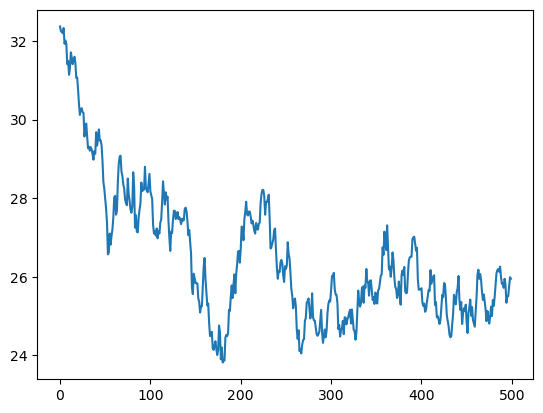

In [ ]:
df["MTNS"].plot()